In [155]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [156]:
df = pd.read_csv('bank.xls')

In [157]:
df.head() 

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


<Axes: >

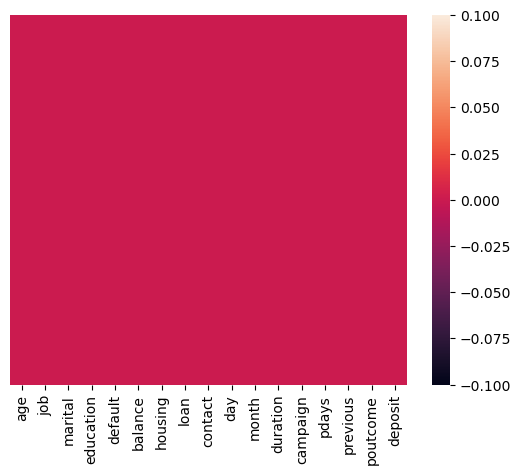

In [158]:
sns.heatmap(df.isnull(),yticklabels=False)

In [159]:
for col in df.columns:
    if col in ['age','balance','day','duration']:
        continue
    print(f"{col:<15} : {df[col].unique()}")

job             : ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
marital         : ['married' 'single' 'divorced']
education       : ['secondary' 'tertiary' 'primary' 'unknown']
default         : ['no' 'yes']
housing         : ['yes' 'no']
loan            : ['no' 'yes']
contact         : ['unknown' 'cellular' 'telephone']
month           : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
campaign        : [ 1  2  3  4  6  5  8 11  9 10 15 12 14  7 24 13 17 29 21 20 16 32 19 25
 22 43 18 41 63 27 30 26 23 28 33 31]
pdays           : [ -1 166  91 147 170 150 171 126 182 110 198 174 175  27 128 100 177 167
 122 183 195 133 178  34  10 163 184 154  99  93   2 242 272  76 160  90
 196 246 238 203 268 189 267  92   9  88  85 210 257 261 270 106 199 112
  41 294 231 239 302 135 307 222 138 323 141 320 264 316 315 256 146 328
  74 148 327 341 145 266 234 345 318 325 2

<Axes: >

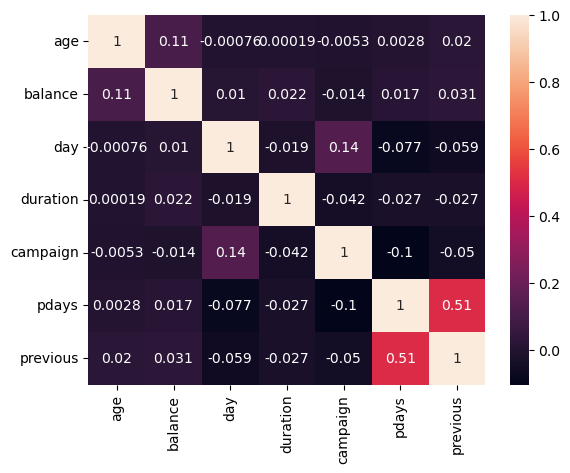

In [160]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [161]:
# the data i want to remove : month, day ,contact* , 

In [162]:
num_cols = ['age','balance','duration','pdays','campaign','previous']

In [163]:
df.drop(['day','month','contact'],inplace=True,axis=1)

In [164]:
df.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,673,2,-1,0,unknown,yes


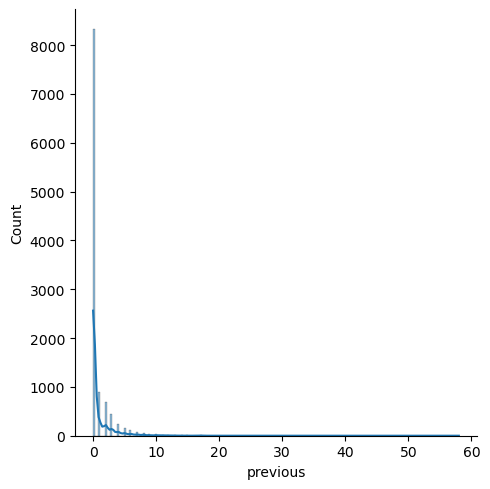

In [165]:
sns.displot(df['previous'],kde=True)

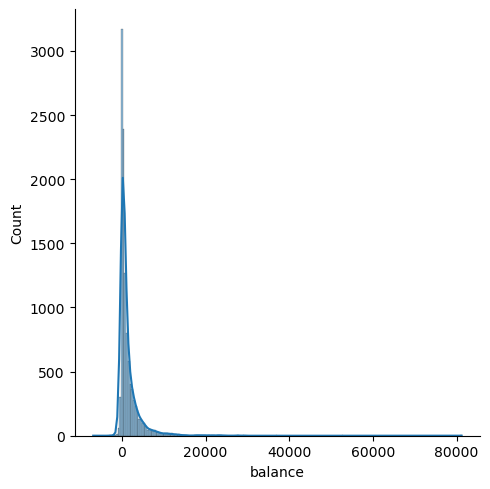

In [166]:
sns.displot(df['balance'],kde=True)

<Axes: ylabel='balance'>

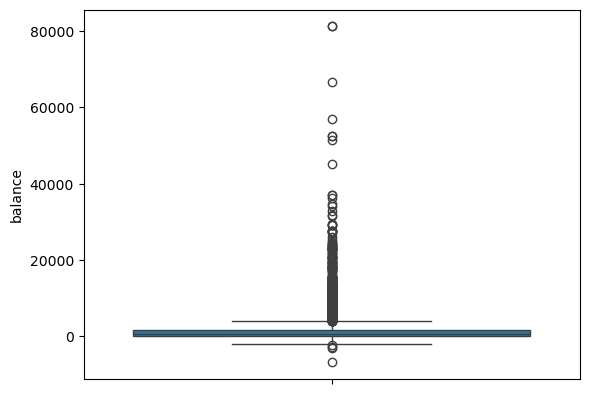

In [167]:
sns.boxplot(df['balance'])

<Axes: xlabel='age', ylabel='balance'>

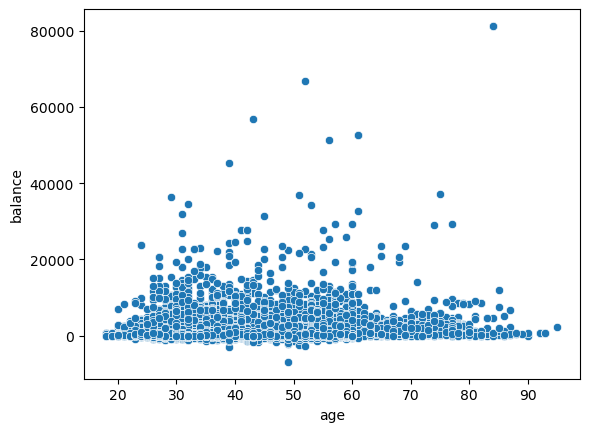

In [168]:
sns.scatterplot(x=df['age'],y=df['balance'])

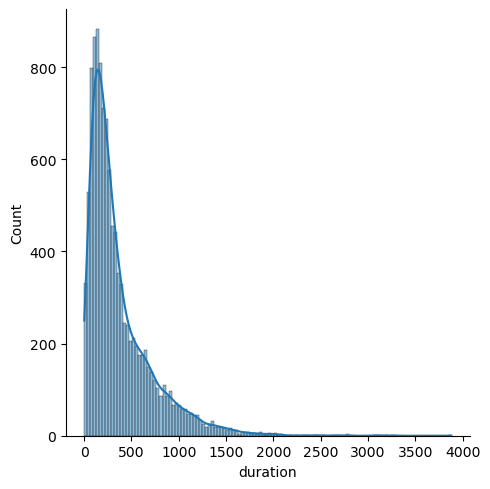

In [169]:
sns.displot(df['duration'],kde=True)

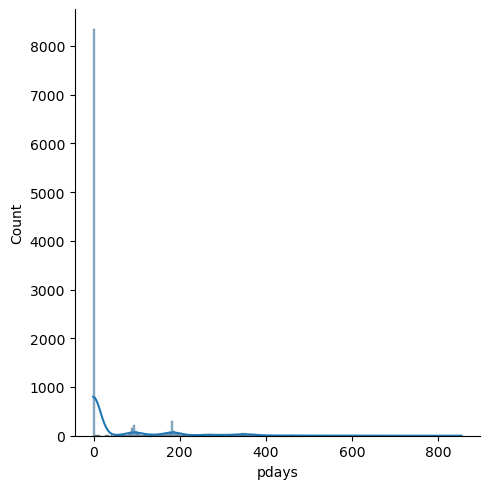

In [170]:
sns.displot(df['pdays'],kde=True)

<Axes: ylabel='pdays'>

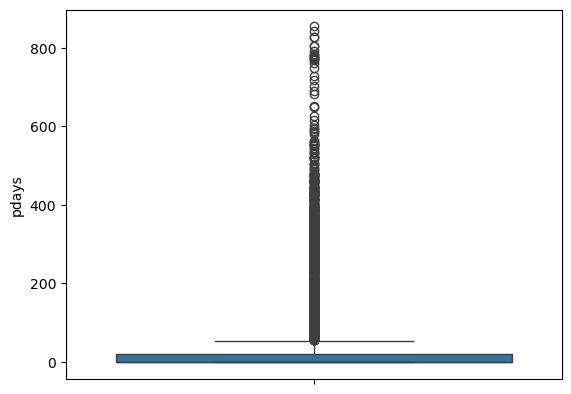

In [171]:
sns.boxplot(df['pdays'])

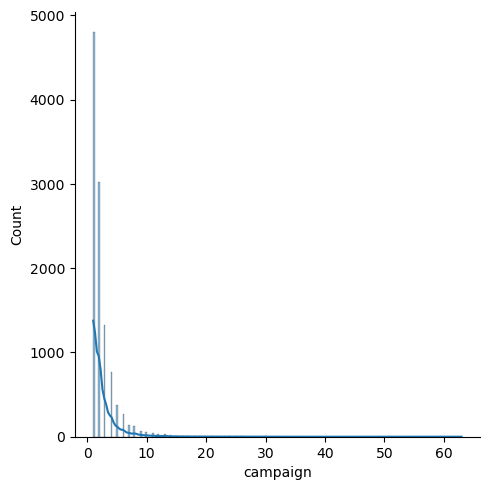

In [172]:
sns.displot(df['campaign'],kde=True)

In [173]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [174]:
new_df = df[num_cols]

In [175]:
new_df.head()

,age,balance,duration,pdays,campaign,previous
0,59,2343,1042,-1,1,0
1,56,45,1467,-1,1,0
2,41,1270,1389,-1,1,0
3,55,2476,579,-1,1,0
4,54,184,673,-1,2,0


In [176]:
new_df[num_cols] = scaler.fit_transform(new_df[num_cols])

C:\Users\susha\AppData\Local\Temp\ipykernel_9316\1912784779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[num_cols] = scaler.fit_transform(new_df[num_cols])


In [177]:
new_df.head()

,age,balance,duration,pdays,campaign,previous
0,1.491505,0.252525,1.930226,-0.481184,-0.554168,-0.36326
1,1.239676,-0.459974,3.154612,-0.481184,-0.554168,-0.36326
2,-0.019470,-0.080160,2.929901,-0.481184,-0.554168,-0.36326
3,1.155733,0.293762,0.596366,-0.481184,-0.554168,-0.36326
4,1.071790,-0.416876,0.867171,-0.481184,-0.186785,-0.36326


In [178]:
# sns.displot(new_df['campaign'],kde=True)job 	marital 	education 	default 	housing 	loan

In [179]:
cat_cols = ['job','marital','education','default','housing','loan','poutcome','deposit']

In [180]:
new_df[cat_cols] = df[cat_cols]

C:\Users\susha\AppData\Local\Temp\ipykernel_9316\3818635368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[cat_cols] = df[cat_cols]
C:\Users\susha\AppData\Local\Temp\ipykernel_9316\3818635368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[cat_cols] = df[cat_cols]
C:\Users\susha\AppData\Local\Temp\ipykernel_9316\3818635368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [181]:
new_df.head() 

,age,balance,duration,pdays,campaign,previous,job,marital,education,default,housing,loan,poutcome,deposit
0,1.491505,0.252525,1.930226,-0.481184,-0.554168,-0.36326,admin.,married,secondary,no,yes,no,unknown,yes
1,1.239676,-0.459974,3.154612,-0.481184,-0.554168,-0.36326,admin.,married,secondary,no,no,no,unknown,yes
2,-0.019470,-0.080160,2.929901,-0.481184,-0.554168,-0.36326,technician,married,secondary,no,yes,no,unknown,yes
3,1.155733,0.293762,0.596366,-0.481184,-0.554168,-0.36326,services,married,secondary,no,yes,no,unknown,yes
4,1.071790,-0.416876,0.867171,-0.481184,-0.186785,-0.36326,admin.,married,tertiary,no,no,no,unknown,yes


In [182]:
cat_cols[:-1]

['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

In [183]:
new_df = pd.get_dummies(new_df,columns=cat_cols[:-1],drop_first=True,dtype=float)

In [184]:
new_df.head() 

,age,balance,duration,pdays,campaign,previous,deposit,job_blue-collar,job_entrepreneur,job_housemaid,...,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,poutcome_other,poutcome_success,poutcome_unknown
0,1.491505,0.252525,1.930226,-0.481184,-0.554168,-0.36326,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.239676,-0.459974,3.154612,-0.481184,-0.554168,-0.36326,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.019470,-0.080160,2.929901,-0.481184,-0.554168,-0.36326,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.155733,0.293762,0.596366,-0.481184,-0.554168,-0.36326,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.071790,-0.416876,0.867171,-0.481184,-0.186785,-0.36326,yes,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [185]:
new_df.columns

Index(['age', 'balance', 'duration', 'pdays', 'campaign', 'previous',
       'deposit', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [186]:
new_df['deposit'] = new_df['deposit'].replace({'yes':1,'no':0})

C:\Users\susha\AppData\Local\Temp\ipykernel_9316\2624290091.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df['deposit'] = new_df['deposit'].replace({'yes':1,'no':0})


In [187]:
y = new_df['deposit']
x= new_df.drop(['deposit'],axis=1)

In [188]:
# y.sample(5)

In [189]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [190]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(max_iter=1000)
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [191]:
y_pred = lg.predict(x_test)

In [192]:
from sklearn.metrics import accuracy_score , roc_auc_score , confusion_matrix , classification_report 
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("ROC Accuracy : ",roc_auc_score(y_test,y_pred))
print("Confusion Matrix :\n",confusion_matrix(y_test,y_pred))
print("Classification Report : ",classification_report(y_test,y_pred))

Accuracy :  0.7969543147208121
ROC Accuracy :  0.7944895994484127
Confusion Matrix :
 [[1483  279]
 [ 401 1186]]
Classification Report :                precision    recall  f1-score   support

           0       0.79      0.84      0.81      1762
           1       0.81      0.75      0.78      1587

    accuracy                           0.80      3349
   macro avg       0.80      0.79      0.80      3349
weighted avg       0.80      0.80      0.80      3349



In [193]:
df.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,673,2,-1,0,unknown,yes


In [194]:
df = pd.get_dummies(df,columns=cat_cols[:-1],drop_first=True,dtype=float)

In [195]:
df.head()

,age,balance,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,job_housemaid,...,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,1042,1,-1,0,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,56,45,1467,1,-1,0,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,41,1270,1389,1,-1,0,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,55,2476,579,1,-1,0,yes,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,54,184,673,2,-1,0,yes,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [196]:
df['deposit'] = df['deposit'].replace({'yes':1,'no':0})

C:\Users\susha\AppData\Local\Temp\ipykernel_9316\4245499360.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['deposit'] = df['deposit'].replace({'yes':1,'no':0})


In [197]:
y2 = df['deposit']
x2 = df.drop(['deposit'],axis=1)

In [198]:
x_train2 , x_test2 , y_train2 , y_test2 = train_test_split(x2,y2,test_size=0.3,random_state=42,stratify=y2)

In [199]:
scaler2 = StandardScaler()
x_train2 = scaler2.fit_transform(x_train2)
x_test2 = scaler2.transform(x_test2)

In [200]:
lg2 = LogisticRegression(max_iter=1000)
lg2.fit(x_train2,y_train2)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [201]:
y_pred2 = lg2.predict(x_test2)

In [202]:
print("Accuracy : ",accuracy_score(y_test2,y_pred2))
print("ROC Accuracy : ",roc_auc_score(y_test2,y_pred2))
print("Confusion Matrix :\n",confusion_matrix(y_test2,y_pred2))
print("Classification Report : ",classification_report(y_test2,y_pred2))

Accuracy :  0.7966557181248134
ROC Accuracy :  0.7942058310034638
Confusion Matrix :
 [[1482  280]
 [ 401 1186]]
Classification Report :                precision    recall  f1-score   support

           0       0.79      0.84      0.81      1762
           1       0.81      0.75      0.78      1587

    accuracy                           0.80      3349
   macro avg       0.80      0.79      0.80      3349
weighted avg       0.80      0.80      0.80      3349



In [203]:
y_prob2 = lg2.predict_proba(x_test2)[:, 1]

print("ROC AUC:", roc_auc_score(y_test2, y_prob2))

ROC AUC: 0.8780353567972466


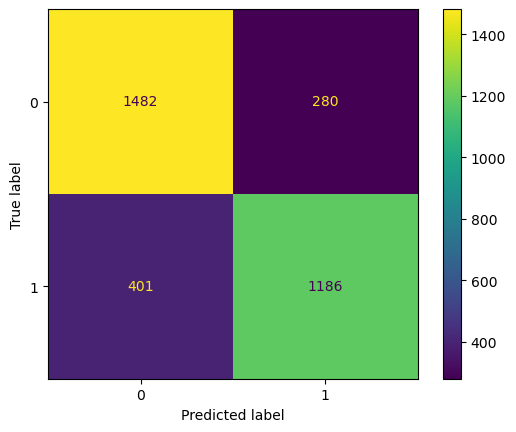

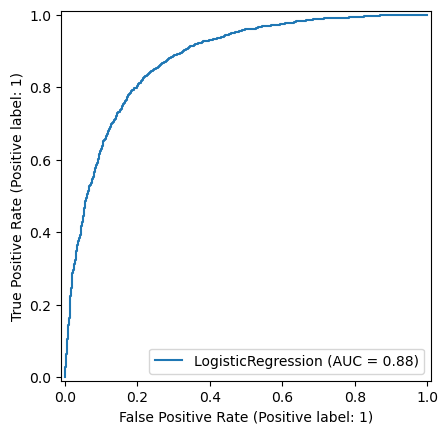

In [204]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lg2, x_test2, y_test2)
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(lg2, x_test2, y_test2)
plt.show()

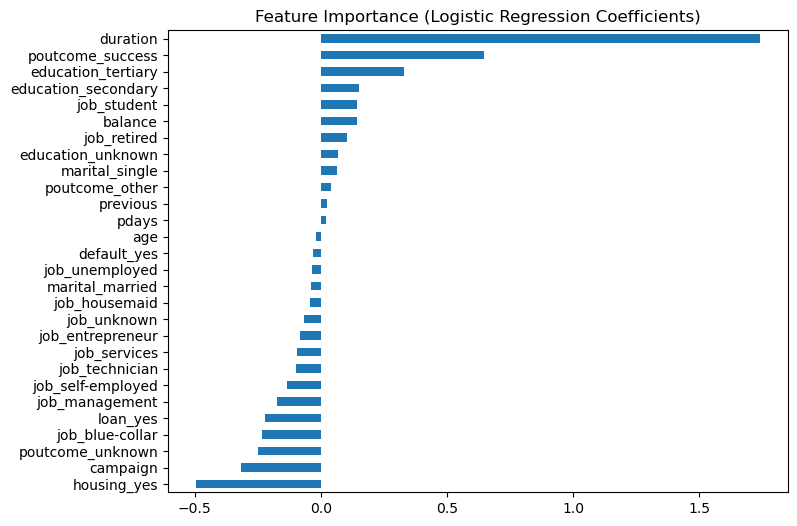

In [205]:
coef = pd.Series(lg2.coef_[0], index=x2.columns)
coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()